# PPO, DDQ, Branching DDQ vs Untrained Compare

Notebook nay so sanh `PPO`, `DDQ` va `Branching DDQ` voi phien ban `untrained` tuong ung tren 12 thang local cuoi cung cua `data/processed_v2`.

Ngoai equity curve, notebook con co:
- drawdown
- rolling Sharpe
- rolling Sortino
- rolling volatility
- histogram daily return
- bang risk summary

Luu y:
- PPO dung env `mode="continuous"`.
- DDQ dung env `mode="discrete"`.
- Branching DDQ dung `mode="MultiDiscrete"` de replay dung action vector per-stock cua checkpoint legacy.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent
if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError(f"Khong tim thay project root hop le tu {NOTEBOOK_DIR}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
torch.set_grad_enabled(False)

PROJECT_ROOT


WindowsPath('D:/HCMUTE/RL/Project')

In [2]:
from src.environment.trading_env import TradingEnv
from src.models.lstm import DRQNNetwork
from src.training.BranchingDDQ import infer_run_config_from_checkpoint as infer_branching_run_config_from_checkpoint
from src.training.DDQ import load_run_config as load_ddq_run_config, resolve_ddq_config
from src.training.PPO import build_reward_kwargs_from_config, load_run_config as load_ppo_run_config
from src.utils.metrics import compute_all
from scripts.dashboard_paths import FIXED_PPO_REPLAY_DEFAULT_CHECKPOINT_ID, FIXED_PPO_REPLAY_RUN_ID
from scripts.zeppelin_checkpoint_replay_helpers import (
    _build_ddq_model,
    _build_model,
    _drawdown_pct_series,
    _make_eval_env,
    _make_eval_env_discrete,
    _rolling_quality_series,
    _run_ddq_episode_values_only,
    _run_ppo_episode_values_only,
)


In [3]:
DATA_ROOT = PROJECT_ROOT / "data" / "processed_v2"
DDQ_CHECKPOINT = PROJECT_ROOT / "results" / "compare" / "DDQ" / "best_model (5).pt"
BRANCHING_CHECKPOINT = PROJECT_ROOT / "results" / "compare" / "BranchingDDQ_LSTM" / "BranchingDDQ.pt"
PPO_RUN_DIR = PROJECT_ROOT / "results" / "runs" / str(FIXED_PPO_REPLAY_RUN_ID or "ppo_20260324_044152")
PPO_CHECKPOINT = PPO_RUN_DIR / "checkpoints" / f"{FIXED_PPO_REPLAY_DEFAULT_CHECKPOINT_ID or 'final_model'}.pt"

DISPLAY_DAYS = 252
ROLLING_WINDOW = 20
RISK_FREE_RATE = 0.045
END_DATE = "2025-12-31"  # Dat None neu muon lay ngay local moi nhat.

assert DATA_ROOT.exists(), DATA_ROOT
assert DDQ_CHECKPOINT.exists(), DDQ_CHECKPOINT
assert BRANCHING_CHECKPOINT.exists(), BRANCHING_CHECKPOINT
assert PPO_RUN_DIR.exists(), PPO_RUN_DIR
assert PPO_CHECKPOINT.exists(), PPO_CHECKPOINT

{
    "data_root": str(DATA_ROOT),
    "ddq_checkpoint": str(DDQ_CHECKPOINT),
    "branching_checkpoint": str(BRANCHING_CHECKPOINT),
    "ppo_run_dir": str(PPO_RUN_DIR),
    "ppo_checkpoint": str(PPO_CHECKPOINT),
    "display_days": DISPLAY_DAYS,
    "rolling_window": ROLLING_WINDOW,
    "risk_free_rate": RISK_FREE_RATE,
    "end_date": END_DATE,
}


{'data_root': 'D:\\HCMUTE\\RL\\Project\\data\\processed_v2',
 'ddq_checkpoint': 'D:\\HCMUTE\\RL\\Project\\results\\compare\\DDQ\\best_model (5).pt',
 'branching_checkpoint': 'D:\\HCMUTE\\RL\\Project\\results\\compare\\BranchingDDQ_LSTM\\BranchingDDQ.pt',
 'ppo_run_dir': 'D:\\HCMUTE\\RL\\Project\\results\\runs\\ppo_20260324_044152',
 'ppo_checkpoint': 'D:\\HCMUTE\\RL\\Project\\results\\runs\\ppo_20260324_044152\\checkpoints\\final_model.pt',
 'display_days': 252,
 'rolling_window': 20,
 'risk_free_rate': 0.045,
 'end_date': '2025-12-31'}

In [4]:
def load_recent_common_data(
    data_root: Path,
    tickers: list[str],
    end_date: str | None,
    keep_days: int,
) -> tuple[dict[str, pd.DataFrame], dict[str, object]]:
    raw_frames: dict[str, pd.DataFrame] = {}
    for ticker in tickers:
        frame = pd.read_csv(data_root / f"{ticker}.csv", parse_dates=["time"])
        frame = frame.sort_values("time").reset_index(drop=True)
        raw_frames[ticker] = frame

    common_dates = sorted(set.intersection(*[set(frame["time"]) for frame in raw_frames.values()]))
    if not common_dates:
        raise ValueError("Khong tim thay common trading dates.")

    effective_end = pd.Timestamp(end_date) if end_date is not None else pd.Timestamp(common_dates[-1])
    clipped_dates = [date for date in common_dates if date <= effective_end]
    if len(clipped_dates) < keep_days:
        raise ValueError(
            f"Khong du {keep_days} ngay giao dich chung truoc {effective_end.date()}. "
            f"Chi co {len(clipped_dates)} ngay."
        )

    selected_dates = pd.DatetimeIndex(clipped_dates[-keep_days:])
    selected_set = set(selected_dates)
    data_dict: dict[str, pd.DataFrame] = {}

    for ticker, frame in raw_frames.items():
        sliced = frame[frame["time"].isin(selected_set)].copy()
        sliced = sliced.sort_values("time").reset_index(drop=True)
        if len(sliced) != len(selected_dates):
            raise ValueError(f"Ticker {ticker} bi lech so ngay sau khi align local replay.")
        data_dict[ticker] = sliced

    meta = {
        "start": str(selected_dates[0].date()),
        "end": str(selected_dates[-1].date()),
        "n_common_days": int(len(selected_dates)),
    }
    return data_dict, meta


def make_branching_eval_env(config: dict, data_dict: dict[str, pd.DataFrame]) -> TradingEnv:
    return TradingEnv(
        tickers=list(config["tickers"]),
        mode="MultiDiscrete",
        initial_balance=float(config["initial_balance"]),
        fee_rate=float(config["fee_rate"]),
        window_size=int(config["window_size"]),
        min_shares=int(config.get("min_shares", 100)),
        data_dict=data_dict,
        features=list(config["features"]),
        max_steps=999999,
        random_start=False,
        reward_scaling=float(config["reward_scaling"]),
        reward_name=str(config["reward_name"]),
        reward_kwargs=build_reward_kwargs_from_config(config),
        trade_deadband=float(config.get("trade_deadband", 0.0)),
        max_weight_change_per_step=float(config.get("max_weight_change_per_step", 1.0)),
        print_verbosity=999999,
    )


class LegacyBranchingPolicy(DRQNNetwork):
    """Legacy branching checkpoint with flat Q-head, reshaped to per-stock actions."""

    def select_action(self, market_state, portfolio_state, hidden=None, epsilon: float = 0.0):
        if float(epsilon) > 0.0 and float(np.random.rand()) < float(epsilon):
            action = np.random.randint(0, self.k, size=(self.n_stocks,), dtype=np.int64)
            with torch.no_grad():
                _, new_hidden = self.forward(market_state, portfolio_state, hidden)
            return action, new_hidden

        with torch.no_grad():
            q_values, new_hidden = self.forward(market_state, portfolio_state, hidden)
            q_values = q_values.view(-1, self.n_stocks, self.k)
            action = q_values.argmax(dim=-1).squeeze(0).cpu().numpy().astype(np.int64)
        return action, new_hidden


def build_untrained_model(config: dict, policy_kind: str = "ddq"):
    torch.manual_seed(int(config.get("seed", 42)))
    if policy_kind == "ppo":
        return _build_model(
            config,
            {
                "kind": "untrained",
                "path": PPO_CHECKPOINT,
                "seed": int(config.get("seed", 42)),
            },
        )

    model_cls = LegacyBranchingPolicy if policy_kind == "branching_legacy" else DRQNNetwork
    model = model_cls(
        n_stocks=len(config["tickers"]),
        n_features=len(config["features"]),
        seq_len=int(config["window_size"]),
        hidden_size=int(config["hidden_size"]),
        num_layers=int(config["num_layers"]),
        dropout=float(config["dropout"]),
        k=int(config.get("k", 3)),
    )
    model.eval()
    return model


def build_branching_model_from_checkpoint(config: dict, checkpoint_path: Path):
    model = build_untrained_model(config, policy_kind="branching_legacy")
    payload = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    state_dict = payload.get("model_state_dict")
    if not isinstance(state_dict, dict):
        raise ValueError(f"Checkpoint Branching khong chua model_state_dict hop le: {checkpoint_path}")
    model.load_state_dict(state_dict)
    model.eval()
    return model


def daily_return_series(values: list[float], initial_balance: float) -> np.ndarray:
    history = np.asarray([float(initial_balance)] + [float(value) for value in values], dtype=np.float64)
    if len(history) < 2:
        return np.asarray([], dtype=np.float64)
    return np.diff(history) / np.maximum(history[:-1], 1e-12)


def rolling_volatility_series(
    values: list[float],
    initial_balance: float,
    window: int = 20,
) -> list[float]:
    returns = daily_return_series(values, initial_balance)
    if len(returns) == 0:
        return []

    effective_window = max(int(window), 5)
    rolling_vol: list[float] = []
    for idx in range(len(returns)):
        start = max(0, idx - effective_window + 1)
        chunk = returns[start : idx + 1]
        if len(chunk) < 2:
            rolling_vol.append(0.0)
        else:
            rolling_vol.append(float(np.std(chunk, ddof=1) * np.sqrt(252.0) * 100.0))
    return rolling_vol


def underwater_duration_series(values: list[float], initial_balance: float) -> list[int]:
    history = np.asarray([float(initial_balance)] + [float(value) for value in values], dtype=np.float64)
    if len(history) < 2:
        return []

    peaks = np.maximum.accumulate(history)
    durations: list[int] = []
    current = 0
    for value, peak in zip(history[1:], peaks[1:]):
        if value < peak:
            current += 1
        else:
            current = 0
        durations.append(current)
    return durations


def evaluate_policy(
    label: str,
    config: dict,
    data_dict: dict[str, pd.DataFrame],
    model,
    env_mode: str,
) -> dict[str, object]:
    initial_balance = float(config["initial_balance"])
    if env_mode == "ppo":
        env = _make_eval_env(config, data_dict)
        start_t = env.state_space.window_size - 1
        values = _run_ppo_episode_values_only(env, model, start_t)
    elif env_mode == "ddq":
        env = _make_eval_env_discrete(config, data_dict)
        start_t = env.state_space.window_size - 1
        values = _run_ddq_episode_values_only(env, model, start_t)
    else:
        env = make_branching_eval_env(config, data_dict)
        start_t = env.state_space.window_size - 1
        values = _run_ddq_episode_values_only(env, model, start_t)
    portfolio_values = [initial_balance] + [float(value) for value in values]

    metrics = compute_all(portfolio_values, initial_balance, risk_free_rate=RISK_FREE_RATE)
    drawdown_pct = _drawdown_pct_series(values, initial_balance)
    rolling_sharpe, rolling_sortino = _rolling_quality_series(
        values,
        initial_balance,
        window=ROLLING_WINDOW,
        risk_free_rate=RISK_FREE_RATE,
    )
    rolling_vol = rolling_volatility_series(values, initial_balance, window=ROLLING_WINDOW)
    daily_returns_pct = daily_return_series(values, initial_balance) * 100.0
    underwater_days = underwater_duration_series(values, initial_balance)
    dates = pd.to_datetime(env.date_memory[1:])

    return {
        "label": label,
        "env_mode": env_mode,
        "dates": dates,
        "values": np.asarray(values, dtype=np.float64),
        "cum_return_pct": ((np.asarray(values, dtype=np.float64) / initial_balance) - 1.0) * 100.0,
        "drawdown_pct": np.asarray(drawdown_pct, dtype=np.float64),
        "rolling_sharpe": np.asarray(rolling_sharpe, dtype=np.float64),
        "rolling_sortino": np.asarray(rolling_sortino, dtype=np.float64),
        "rolling_vol_pct": np.asarray(rolling_vol, dtype=np.float64),
        "daily_returns_pct": np.asarray(daily_returns_pct, dtype=np.float64),
        "underwater_days": np.asarray(underwater_days, dtype=np.int64),
        "metrics": metrics,
        "initial_balance": initial_balance,
    }


In [5]:
ddq_config = load_ddq_run_config(
    DDQ_CHECKPOINT.parent,
    overrides={"device": "cpu", "data_path": str(DATA_ROOT)},
)
branching_base_config = resolve_ddq_config(
    config_path=PROJECT_ROOT / "Conf" / "branching_ddq_conf.yaml",
)
branching_base_config.update({"device": "cpu", "data_path": str(DATA_ROOT)})
branching_config = infer_branching_run_config_from_checkpoint(
    BRANCHING_CHECKPOINT,
    base_config=branching_base_config,
    overrides={"device": "cpu", "data_path": str(DATA_ROOT)},
)
ppo_config = load_ppo_run_config(
    PPO_RUN_DIR,
    overrides={"device": "cpu", "data_path": str(DATA_ROOT)},
)

shared_tickers = [str(item).upper() for item in ddq_config["tickers"]]
if shared_tickers != [str(item).upper() for item in branching_config["tickers"]]:
    raise ValueError("DDQ va Branching DDQ dang khong cung ro ticker, khong the compare truc tiep.")
if shared_tickers != [str(item).upper() for item in ppo_config["tickers"]]:
    raise ValueError("PPO dang khong cung ro ticker voi DDQ/Branching DDQ, khong the compare truc tiep.")

keep_days = DISPLAY_DAYS + max(
    int(ddq_config["window_size"]),
    int(branching_config["window_size"]),
    int(ppo_config["window_size"]),
)
data_dict, dataset_meta = load_recent_common_data(
    data_root=DATA_ROOT,
    tickers=list(ddq_config["tickers"]),
    end_date=END_DATE,
    keep_days=keep_days,
)

results = {
    "ppo_trained": evaluate_policy(
        label="PPO trained",
        config=ppo_config,
        data_dict=data_dict,
        model=_build_model(
            ppo_config,
            {
                "kind": str(PPO_CHECKPOINT.stem),
                "path": PPO_CHECKPOINT,
                "seed": int(ppo_config.get("seed", 42)),
            },
        ),
        env_mode="ppo",
    ),
    "ppo_untrained": evaluate_policy(
        label="PPO untrained",
        config=ppo_config,
        data_dict=data_dict,
        model=build_untrained_model(ppo_config, policy_kind="ppo"),
        env_mode="ppo",
    ),
    "ddq_trained": evaluate_policy(
        label="DDQ trained",
        config=ddq_config,
        data_dict=data_dict,
        model=_build_ddq_model(ddq_config, DDQ_CHECKPOINT),
        env_mode="ddq",
    ),
    "ddq_untrained": evaluate_policy(
        label="DDQ untrained",
        config=ddq_config,
        data_dict=data_dict,
        model=build_untrained_model(ddq_config, policy_kind="ddq"),
        env_mode="ddq",
    ),
    "branching_trained": evaluate_policy(
        label="Branching DDQ trained",
        config=branching_config,
        data_dict=data_dict,
        model=build_branching_model_from_checkpoint(branching_config, BRANCHING_CHECKPOINT),
        env_mode="branching",
    ),
    "branching_untrained": evaluate_policy(
        label="Branching DDQ untrained",
        config=branching_config,
        data_dict=data_dict,
        model=build_untrained_model(branching_config, policy_kind="branching_legacy"),
        env_mode="branching",
    ),
}

dataset_meta["effective_steps"] = int(len(results["ppo_trained"]["values"]))
dataset_meta["tickers"] = int(len(ddq_config["tickers"]))
dataset_meta["ddq_features"] = int(len(ddq_config["features"]))
dataset_meta["branching_features"] = int(len(branching_config["features"]))
dataset_meta["ppo_features"] = int(len(ppo_config["features"]))

artifact_df = pd.DataFrame(
    [
        {
            "artifact": "PPO",
            "checkpoint": str(PPO_CHECKPOINT),
            "window_size": int(ppo_config["window_size"]),
            "hidden_size": int(ppo_config["hidden_size"]),
            "num_layers": int(ppo_config["num_layers"]),
            "dropout": float(ppo_config["dropout"]),
            "k": np.nan,
            "seed": int(ppo_config.get("seed", 42)),
        },
        {
            "artifact": "DDQ",
            "checkpoint": str(DDQ_CHECKPOINT),
            "window_size": int(ddq_config["window_size"]),
            "hidden_size": int(ddq_config["hidden_size"]),
            "num_layers": int(ddq_config["num_layers"]),
            "dropout": float(ddq_config["dropout"]),
            "k": int(ddq_config.get("k", 3)),
            "seed": int(ddq_config.get("seed", 42)),
        },
        {
            "artifact": "Branching DDQ",
            "checkpoint": str(BRANCHING_CHECKPOINT),
            "window_size": int(branching_config["window_size"]),
            "hidden_size": int(branching_config["hidden_size"]),
            "num_layers": int(branching_config["num_layers"]),
            "dropout": float(branching_config["dropout"]),
            "k": int(branching_config.get("k", 3)),
            "seed": int(branching_config.get("seed", 42)),
        },
    ]
)

display(pd.DataFrame([dataset_meta]))
display(artifact_df)


,start,end,n_common_days,effective_steps,tickers,ddq_features,branching_features,ppo_features
0,2024-10-04,2025-12-31,312,252,16,7,9,9


,artifact,checkpoint,window_size,hidden_size,num_layers,dropout,k,seed
0,PPO,D:\HCMUTE\RL\Project\results\runs\ppo_20260324...,60,128,2,0.1,NaN,42
1,DDQ,D:\HCMUTE\RL\Project\results\compare\DDQ\best_...,60,128,2,0.1,3.0,42
2,Branching DDQ,D:\HCMUTE\RL\Project\results\compare\Branching...,60,128,2,0.1,3.0,42


In [6]:
pair_map = {
    "ppo_trained": "ppo_untrained",
    "ppo_untrained": "ppo_untrained",
    "ddq_trained": "ddq_untrained",
    "ddq_untrained": "ddq_untrained",
    "branching_trained": "branching_untrained",
    "branching_untrained": "branching_untrained",
}

summary_rows = []
for key, result in results.items():
    metrics = result["metrics"]
    pair_key = pair_map[key]
    pair_metrics = results[pair_key]["metrics"]
    if key.startswith("ppo_"):
        group = "PPO"
    elif key.startswith("ddq_"):
        group = "DDQ"
    else:
        group = "Branching DDQ"

    summary_rows.append(
        {
            "policy": result["label"],
            "group": group,
            "total_return_pct": metrics.get("total_return", 0.0) * 100.0,
            "annualized_return_pct": metrics.get("annualized_return", 0.0) * 100.0,
            "annualized_vol_pct": metrics.get("annualized_vol", 0.0) * 100.0,
            "sharpe_ratio": metrics.get("sharpe_ratio", 0.0),
            "sortino_ratio": metrics.get("sortino_ratio", 0.0),
            "calmar_ratio": metrics.get("calmar_ratio", 0.0),
            "max_drawdown_pct": metrics.get("max_drawdown", 0.0) * 100.0,
            "max_drawdown_duration": metrics.get("max_drawdown_duration", 0),
            "max_underwater_days": int(np.max(result["underwater_days"])) if len(result["underwater_days"]) else 0,
            "win_rate_pct": metrics.get("win_rate", 0.0) * 100.0,
            "profit_factor": metrics.get("profit_factor", 0.0),
            "var_95_pct": metrics.get("var_95", 0.0) * 100.0,
            "cvar_95_pct": metrics.get("cvar_95", 0.0) * 100.0,
            "delta_vs_pair_return_pct": (metrics.get("total_return", 0.0) - pair_metrics.get("total_return", 0.0)) * 100.0,
            "delta_vs_pair_sharpe": metrics.get("sharpe_ratio", 0.0) - pair_metrics.get("sharpe_ratio", 0.0),
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.round(4).sort_values(["group", "policy"]).reset_index(drop=True)
display(summary_df)


,policy,group,total_return_pct,annualized_return_pct,annualized_vol_pct,sharpe_ratio,sortino_ratio,calmar_ratio,max_drawdown_pct,max_drawdown_duration,max_underwater_days,win_rate_pct,profit_factor,var_95_pct,cvar_95_pct,delta_vs_pair_return_pct,delta_vs_pair_sharpe
0,Branching DDQ trained,Branching DDQ,30.7066,30.7066,27.1956,0.9548,1.0009,1.1932,25.7354,46,46,53.1746,1.2472,2.6447,3.9553,-224.0990,-2.9312
1,Branching DDQ untrained,Branching DDQ,254.8056,254.8056,32.8925,3.8860,4.2409,16.1660,15.7619,31,31,61.1111,2.0455,2.8340,4.1650,0.0000,0.0000
2,DDQ trained,DDQ,176.4071,176.4071,36.6165,2.8401,3.7613,11.7760,14.9802,48,48,44.0476,1.8681,2.9974,4.8361,161.8064,2.3972
3,DDQ untrained,DDQ,14.6007,14.6007,32.5540,0.4429,0.4670,0.4991,29.2546,77,77,46.4286,1.1165,2.7195,5.0024,0.0000,0.0000
4,PPO trained,PPO,37.4713,37.4713,20.1277,1.4593,1.3261,2.1517,17.4146,51,51,58.7302,1.3991,1.3435,3.1898,1.4369,0.0334
5,PPO untrained,PPO,36.0345,36.0345,19.8190,1.4259,1.3007,2.1165,17.0254,54,54,57.9365,1.3908,1.3419,3.1609,0.0000,0.0000


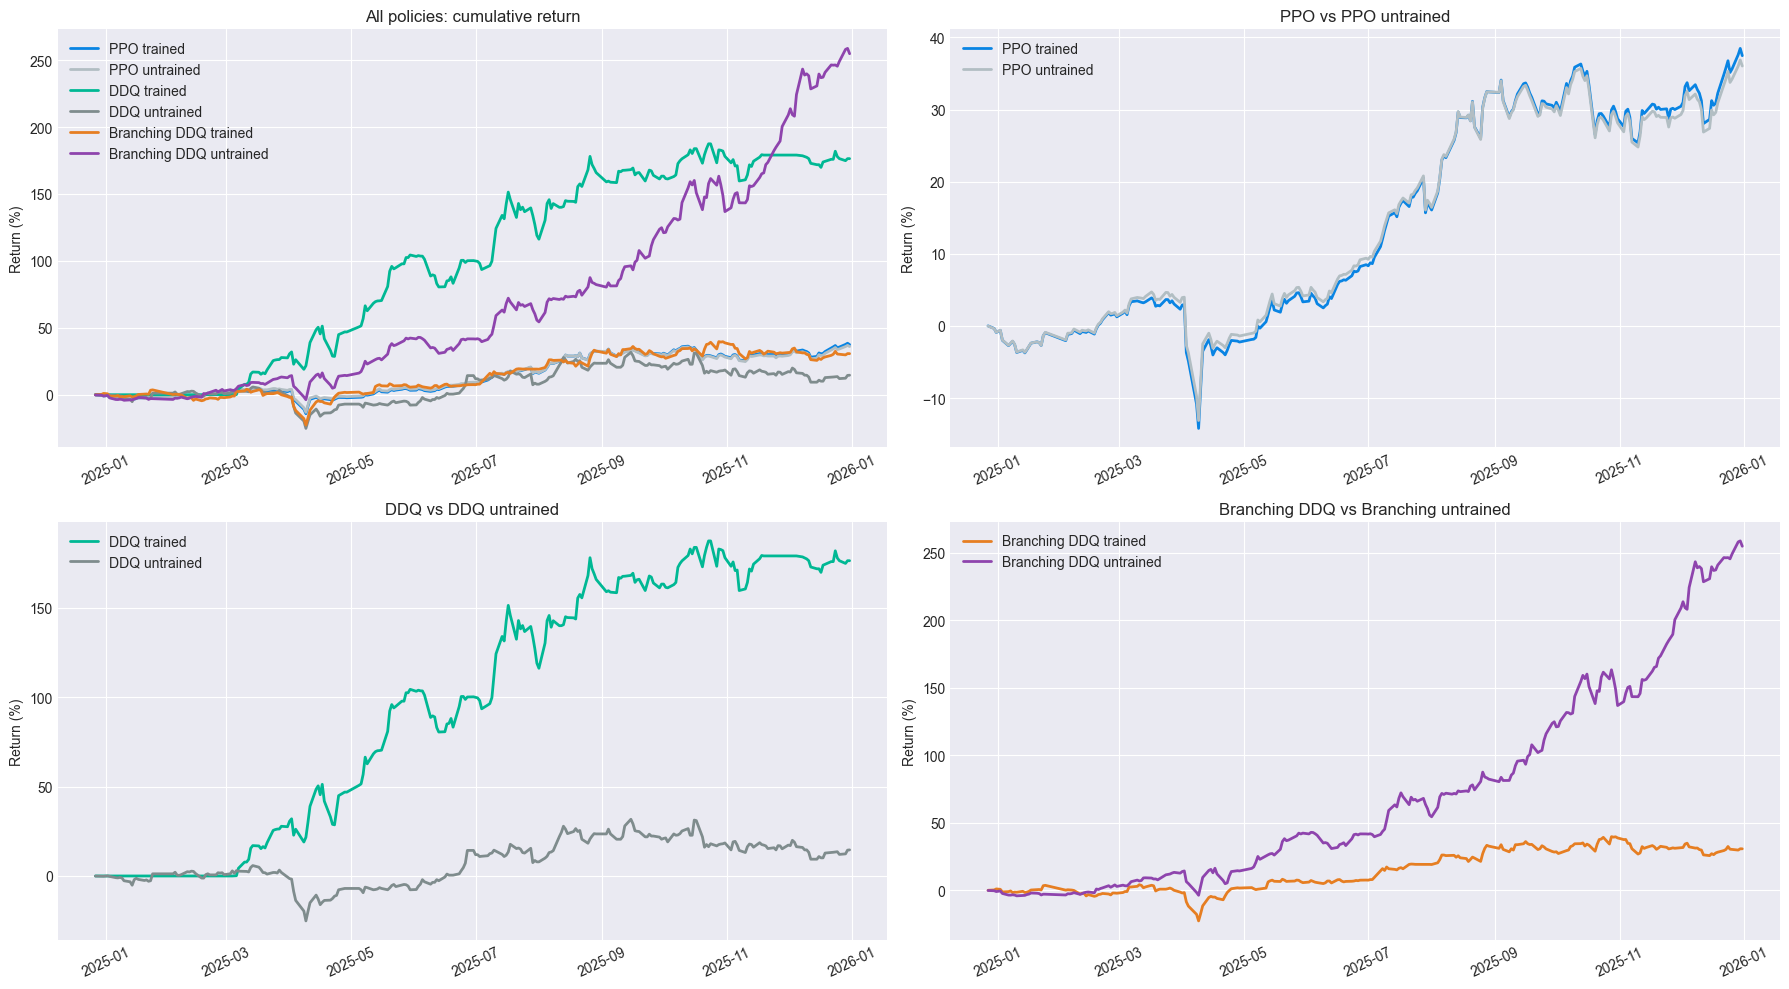

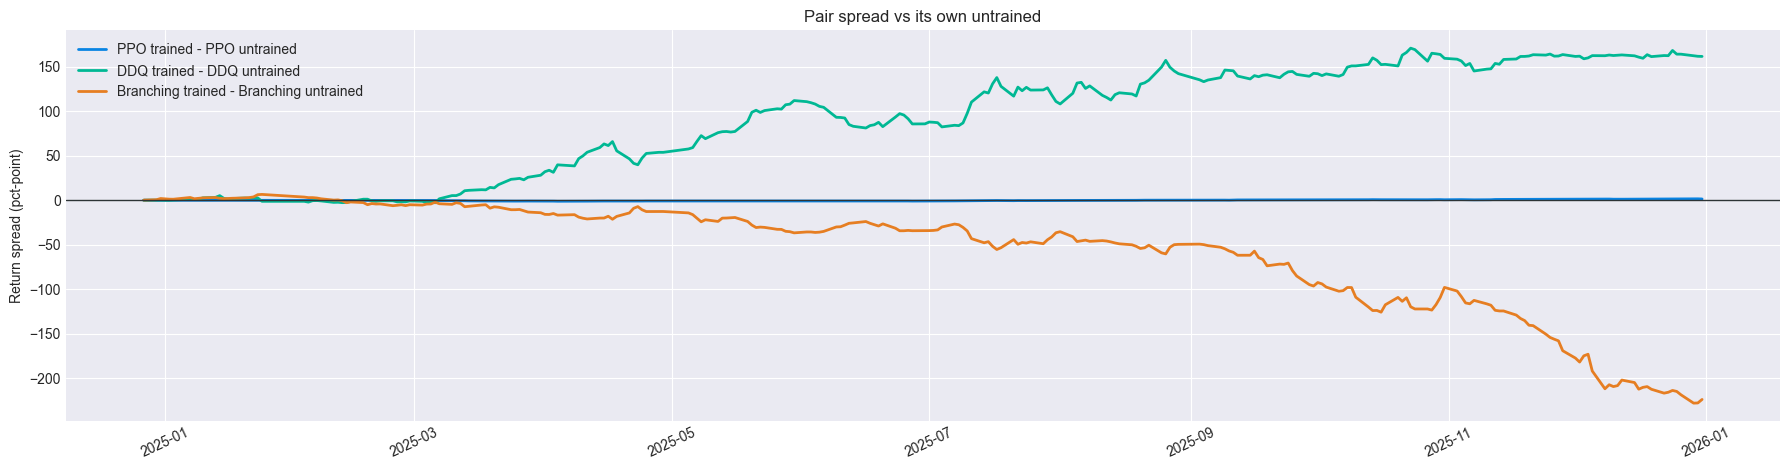

In [7]:
plot_colors = {
    "ppo_trained": "#0984e3",
    "ppo_untrained": "#b2bec3",
    "ddq_trained": "#00b894",
    "ddq_untrained": "#7f8c8d",
    "branching_trained": "#e67e22",
    "branching_untrained": "#8e44ad",
}

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for key in [
    "ppo_trained",
    "ppo_untrained",
    "ddq_trained",
    "ddq_untrained",
    "branching_trained",
    "branching_untrained",
]:
    result = results[key]
    axes[0, 0].plot(result["dates"], result["cum_return_pct"], label=result["label"], lw=2.0, color=plot_colors[key])
axes[0, 0].set_title("All policies: cumulative return")
axes[0, 0].set_ylabel("Return (%)")
axes[0, 0].legend()

for key in ["ppo_trained", "ppo_untrained"]:
    result = results[key]
    axes[0, 1].plot(result["dates"], result["cum_return_pct"], label=result["label"], lw=2.0, color=plot_colors[key])
axes[0, 1].set_title("PPO vs PPO untrained")
axes[0, 1].set_ylabel("Return (%)")
axes[0, 1].legend()

for key in ["ddq_trained", "ddq_untrained"]:
    result = results[key]
    axes[1, 0].plot(result["dates"], result["cum_return_pct"], label=result["label"], lw=2.0, color=plot_colors[key])
axes[1, 0].set_title("DDQ vs DDQ untrained")
axes[1, 0].set_ylabel("Return (%)")
axes[1, 0].legend()

for key in ["branching_trained", "branching_untrained"]:
    result = results[key]
    axes[1, 1].plot(result["dates"], result["cum_return_pct"], label=result["label"], lw=2.0, color=plot_colors[key])
axes[1, 1].set_title("Branching DDQ vs Branching untrained")
axes[1, 1].set_ylabel("Return (%)")
axes[1, 1].legend()

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(18, 4.8))
ppo_spread = results["ppo_trained"]["cum_return_pct"] - results["ppo_untrained"]["cum_return_pct"]
ddq_spread = results["ddq_trained"]["cum_return_pct"] - results["ddq_untrained"]["cum_return_pct"]
branch_spread = results["branching_trained"]["cum_return_pct"] - results["branching_untrained"]["cum_return_pct"]
ax.plot(results["ppo_trained"]["dates"], ppo_spread, label="PPO trained - PPO untrained", lw=2.0, color=plot_colors["ppo_trained"])
ax.plot(results["ddq_trained"]["dates"], ddq_spread, label="DDQ trained - DDQ untrained", lw=2.0, color=plot_colors["ddq_trained"])
ax.plot(results["branching_trained"]["dates"], branch_spread, label="Branching trained - Branching untrained", lw=2.0, color=plot_colors["branching_trained"])
ax.axhline(0.0, color="#2d3436", lw=1.0)
ax.set_title("Pair spread vs its own untrained")
ax.set_ylabel("Return spread (pct-point)")
ax.legend()
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


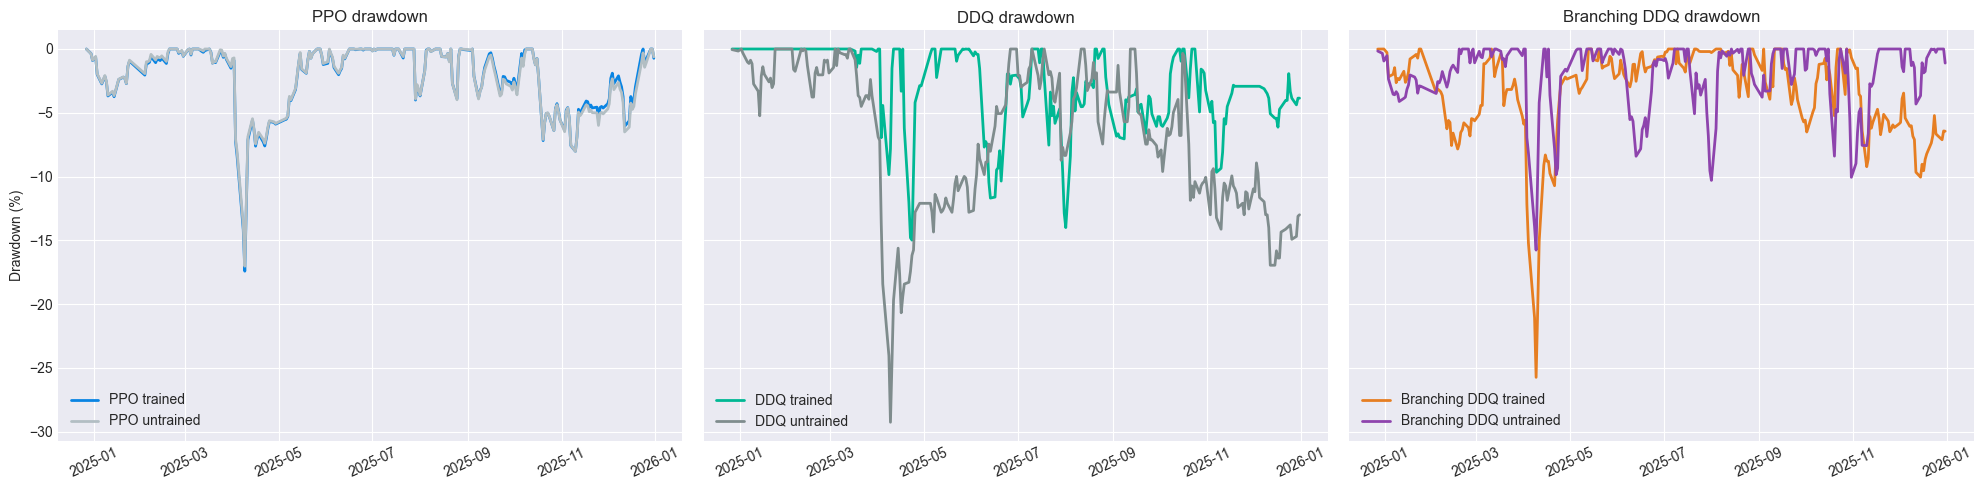

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for key in ["ppo_trained", "ppo_untrained"]:
    result = results[key]
    axes[0].plot(result["dates"], result["drawdown_pct"], label=result["label"], lw=2.0, color=plot_colors[key])
axes[0].set_title("PPO drawdown")
axes[0].set_ylabel("Drawdown (%)")
axes[0].legend()

for key in ["ddq_trained", "ddq_untrained"]:
    result = results[key]
    axes[1].plot(result["dates"], result["drawdown_pct"], label=result["label"], lw=2.0, color=plot_colors[key])
axes[1].set_title("DDQ drawdown")
axes[1].legend()

for key in ["branching_trained", "branching_untrained"]:
    result = results[key]
    axes[2].plot(result["dates"], result["drawdown_pct"], label=result["label"], lw=2.0, color=plot_colors[key])
axes[2].set_title("Branching DDQ drawdown")
axes[2].legend()

for ax in axes:
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


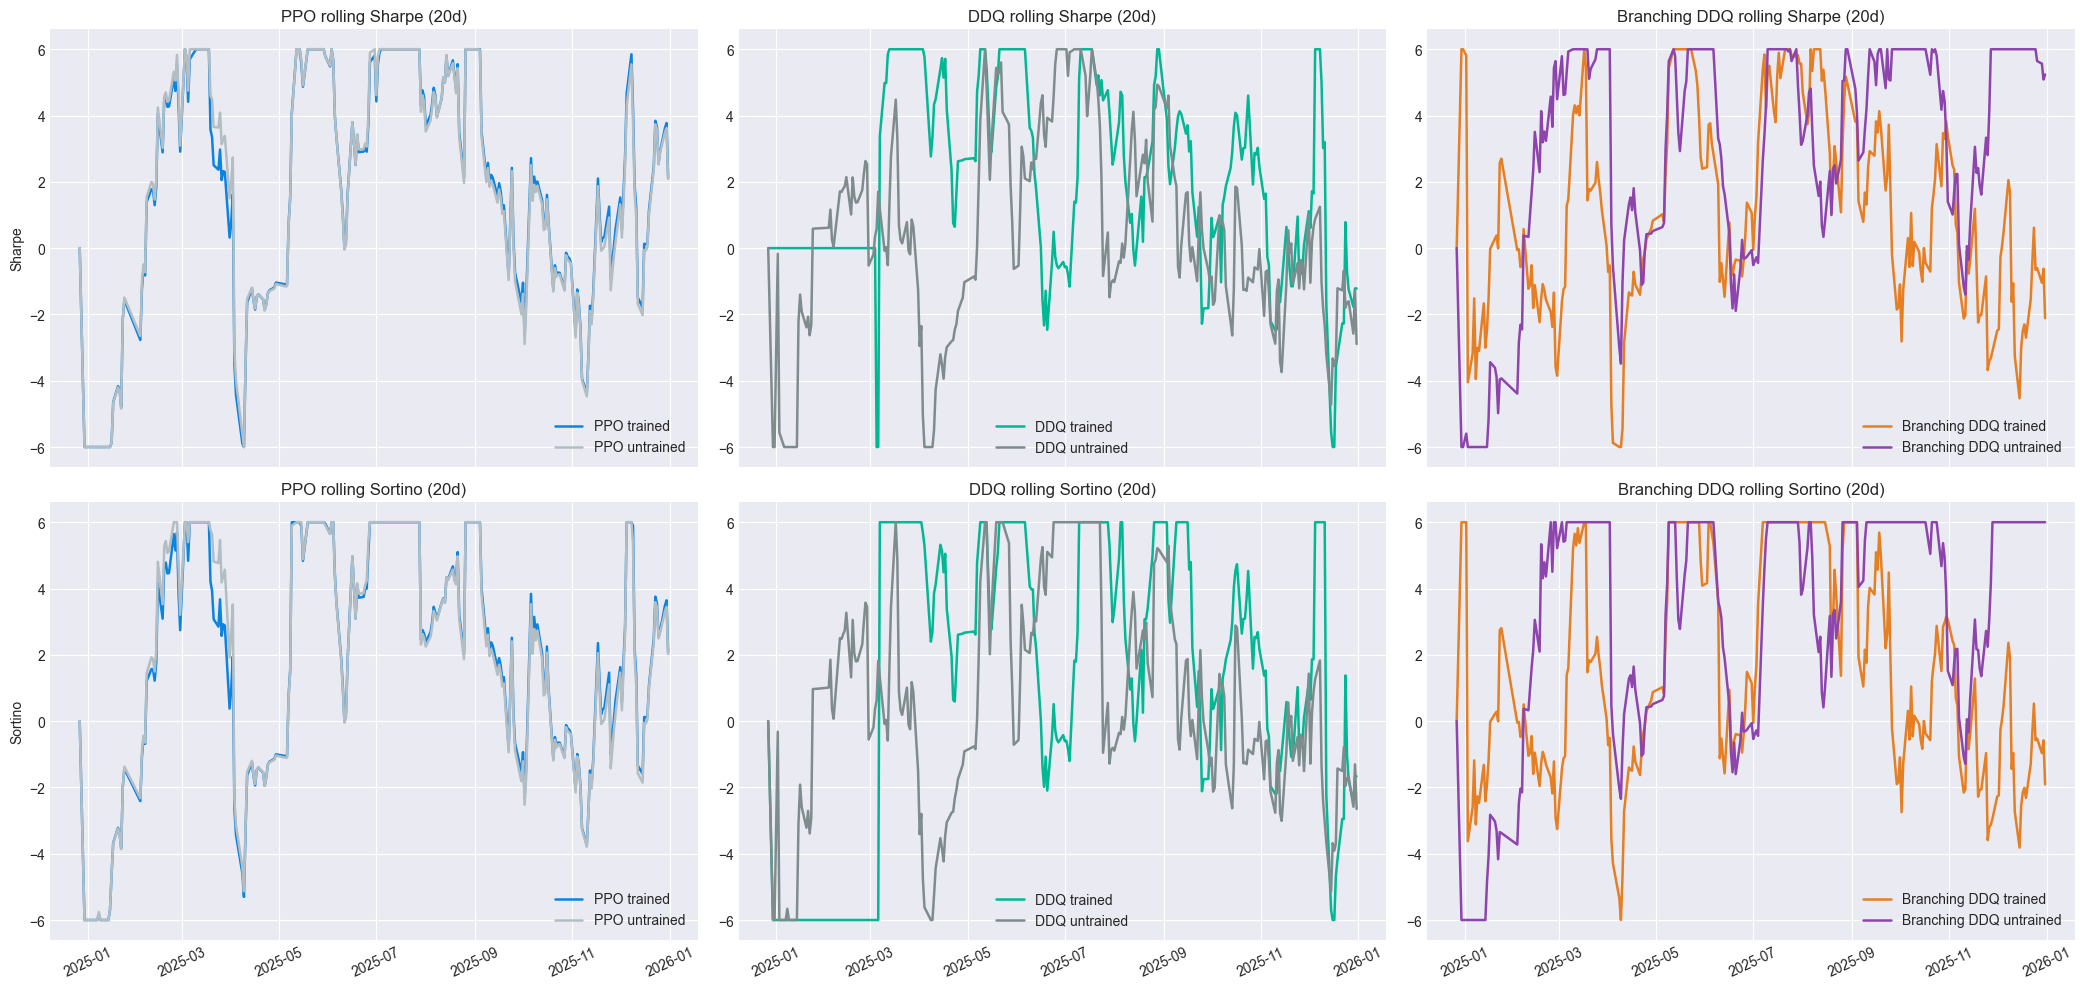

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(21, 10), sharex=True)

for key in ["ppo_trained", "ppo_untrained"]:
    result = results[key]
    axes[0, 0].plot(result["dates"], result["rolling_sharpe"], label=result["label"], lw=1.8, color=plot_colors[key])
axes[0, 0].set_title(f"PPO rolling Sharpe ({ROLLING_WINDOW}d)")
axes[0, 0].set_ylabel("Sharpe")
axes[0, 0].legend()

for key in ["ddq_trained", "ddq_untrained"]:
    result = results[key]
    axes[0, 1].plot(result["dates"], result["rolling_sharpe"], label=result["label"], lw=1.8, color=plot_colors[key])
axes[0, 1].set_title(f"DDQ rolling Sharpe ({ROLLING_WINDOW}d)")
axes[0, 1].legend()

for key in ["branching_trained", "branching_untrained"]:
    result = results[key]
    axes[0, 2].plot(result["dates"], result["rolling_sharpe"], label=result["label"], lw=1.8, color=plot_colors[key])
axes[0, 2].set_title(f"Branching DDQ rolling Sharpe ({ROLLING_WINDOW}d)")
axes[0, 2].legend()

for key in ["ppo_trained", "ppo_untrained"]:
    result = results[key]
    axes[1, 0].plot(result["dates"], result["rolling_sortino"], label=result["label"], lw=1.8, color=plot_colors[key])
axes[1, 0].set_title(f"PPO rolling Sortino ({ROLLING_WINDOW}d)")
axes[1, 0].set_ylabel("Sortino")
axes[1, 0].legend()

for key in ["ddq_trained", "ddq_untrained"]:
    result = results[key]
    axes[1, 1].plot(result["dates"], result["rolling_sortino"], label=result["label"], lw=1.8, color=plot_colors[key])
axes[1, 1].set_title(f"DDQ rolling Sortino ({ROLLING_WINDOW}d)")
axes[1, 1].legend()

for key in ["branching_trained", "branching_untrained"]:
    result = results[key]
    axes[1, 2].plot(result["dates"], result["rolling_sortino"], label=result["label"], lw=1.8, color=plot_colors[key])
axes[1, 2].set_title(f"Branching DDQ rolling Sortino ({ROLLING_WINDOW}d)")
axes[1, 2].legend()

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


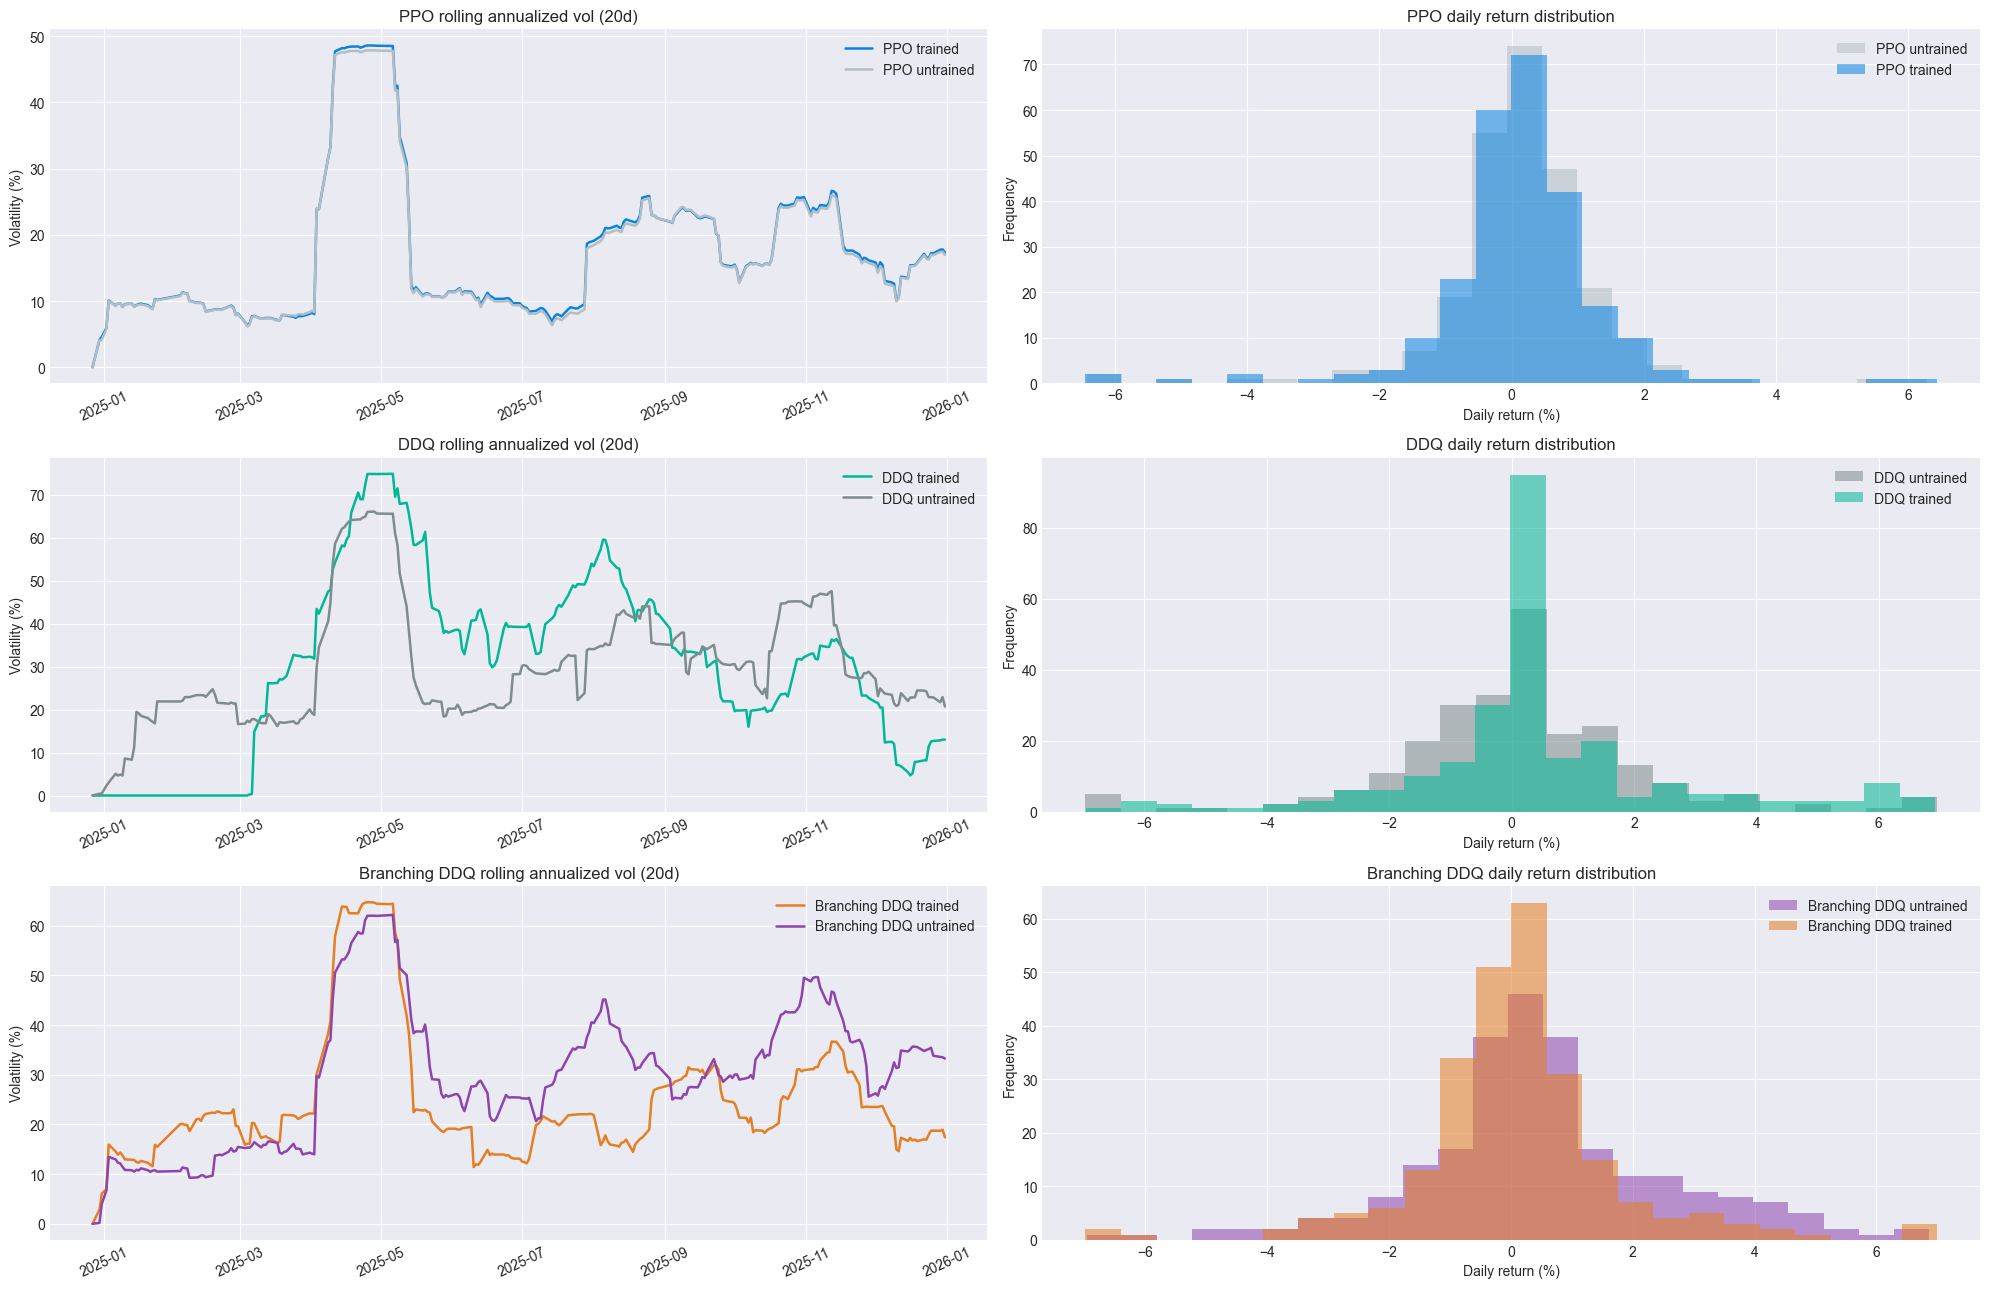

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(20, 13))

for key in ["ppo_trained", "ppo_untrained"]:
    result = results[key]
    axes[0, 0].plot(result["dates"], result["rolling_vol_pct"], label=result["label"], lw=1.8, color=plot_colors[key])
axes[0, 0].set_title(f"PPO rolling annualized vol ({ROLLING_WINDOW}d)")
axes[0, 0].set_ylabel("Volatility (%)")
axes[0, 0].legend()

axes[0, 1].hist(results["ppo_untrained"]["daily_returns_pct"], bins=24, alpha=0.55, label=results["ppo_untrained"]["label"], color=plot_colors["ppo_untrained"])
axes[0, 1].hist(results["ppo_trained"]["daily_returns_pct"], bins=24, alpha=0.55, label=results["ppo_trained"]["label"], color=plot_colors["ppo_trained"])
axes[0, 1].set_title("PPO daily return distribution")
axes[0, 1].set_xlabel("Daily return (%)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].legend()

for key in ["ddq_trained", "ddq_untrained"]:
    result = results[key]
    axes[1, 0].plot(result["dates"], result["rolling_vol_pct"], label=result["label"], lw=1.8, color=plot_colors[key])
axes[1, 0].set_title(f"DDQ rolling annualized vol ({ROLLING_WINDOW}d)")
axes[1, 0].set_ylabel("Volatility (%)")
axes[1, 0].legend()

axes[1, 1].hist(results["ddq_untrained"]["daily_returns_pct"], bins=24, alpha=0.55, label=results["ddq_untrained"]["label"], color=plot_colors["ddq_untrained"])
axes[1, 1].hist(results["ddq_trained"]["daily_returns_pct"], bins=24, alpha=0.55, label=results["ddq_trained"]["label"], color=plot_colors["ddq_trained"])
axes[1, 1].set_title("DDQ daily return distribution")
axes[1, 1].set_xlabel("Daily return (%)")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].legend()

for key in ["branching_trained", "branching_untrained"]:
    result = results[key]
    axes[2, 0].plot(result["dates"], result["rolling_vol_pct"], label=result["label"], lw=1.8, color=plot_colors[key])
axes[2, 0].set_title(f"Branching DDQ rolling annualized vol ({ROLLING_WINDOW}d)")
axes[2, 0].set_ylabel("Volatility (%)")
axes[2, 0].legend()

axes[2, 1].hist(results["branching_untrained"]["daily_returns_pct"], bins=24, alpha=0.55, label=results["branching_untrained"]["label"], color=plot_colors["branching_untrained"])
axes[2, 1].hist(results["branching_trained"]["daily_returns_pct"], bins=24, alpha=0.55, label=results["branching_trained"]["label"], color=plot_colors["branching_trained"])
axes[2, 1].set_title("Branching DDQ daily return distribution")
axes[2, 1].set_xlabel("Daily return (%)")
axes[2, 1].set_ylabel("Frequency")
axes[2, 1].legend()

for ax in axes[:, 0]:
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()
